In [1]:
#Reading the Data files
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

analysis = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/analysis_data.csv')
scoring = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/scoring_data.csv')

In [2]:
#Importing Libraries and functions to be used 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
#Splitting the analysis data
train = analysis.sample(frac=0.7, random_state=1031)
test = analysis.drop(labels = train.index)

In [4]:
#Specifying the variables in the train data split
y_train = train['monthly_spend']
X_train = train.drop('monthly_spend', axis=1)

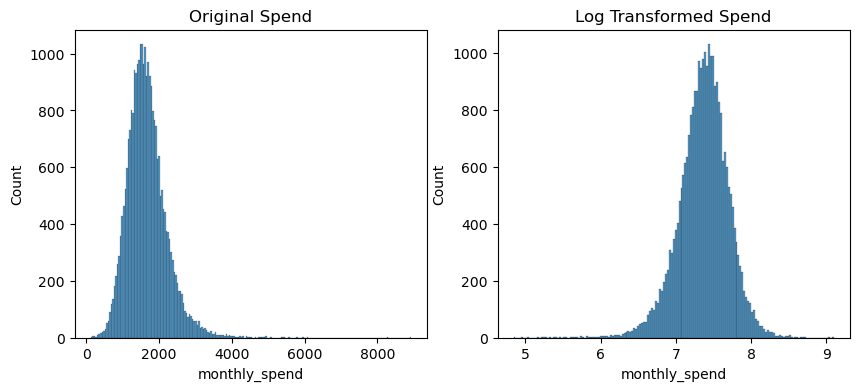

In [5]:
# --- ADDITION: Log Transform Target ---
# We predict log(spend) instead of spend. 
# This pulls in the outliers and stabilizes the variance.
y_train_log = np.log1p(y_train) 

# Check the distribution (optional visualization)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); sns.histplot(y_train); plt.title("Original Spend")
plt.subplot(1,2,2); sns.histplot(y_train_log); plt.title("Log Transformed Spend")
plt.show()

In [6]:
#Rectifying the NAs
# add missingness indicators (helps models learn if "missing" is informative)
X_train['online_shopping_freq_was_na']  = X_train['online_shopping_freq'].isna().astype(int)
X_train['utility_payment_count_was_na'] = X_train['utility_payment_count'].isna().astype(int)
X_train['education_level_was_na']       = X_train['education_level'].isna().astype(int)

# numeric counts -> median inputes of the rest of data
X_train['online_shopping_freq']  = X_train['online_shopping_freq'].fillna(X_train['online_shopping_freq'].median())
X_train['utility_payment_count'] = X_train['utility_payment_count'].fillna(X_train['utility_payment_count'].median())

# categorical -> mode inputes of the rest of data
edu_mode = X_train['education_level'].mode(dropna=True)
edu_fill = edu_mode.iloc[0] if len(edu_mode) else 'Unknown'
X_train['education_level'] = X_train['education_level'].fillna(edu_fill)

In [7]:
#Rechecking for NAs after the recti
print(X_train.isnull().sum().sort_values(ascending=False).head(10))

customer_id                     0
card_type                       0
utility_payment_count_was_na    0
online_shopping_freq_was_na     0
num_credit_cards                0
num_children                    0
utility_payment_count           0
travel_frequency                0
reward_points_balance           0
online_shopping_freq            0
dtype: int64


In [8]:
#Segregating the categorical stuff
categorical_features = [
    'gender', 'marital_status', 'education_level',
    'region', 'employment_status', 'card_type'
]

In [9]:
#Creating dummies
X_train_dum = pd.get_dummies(
    X_train,
    columns=[c for c in categorical_features if c in X_train.columns],
    drop_first=True,
    prefix_sep='_'
)

In [10]:
#Checking on the data
print('Shape before dummies:', X_train.shape)
print('Shape after dummies:',  X_train_dum.shape)
print('Object dtypes remaining (should be 0):', X_train_dum.select_dtypes(include='object').shape[1])
print('Preview columns:', list(X_train_dum.columns[:12]))
print(X_train_dum.dtypes)

Shape before dummies: (28000, 25)
Shape after dummies: (28000, 31)
Object dtypes remaining (should be 0): 0
Preview columns: ['customer_id', 'age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score', 'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value', 'online_shopping_freq', 'reward_points_balance']
customer_id                          int64
age                                  int64
owns_home                            int64
has_auto_loan                        int64
annual_income                      float64
credit_score                       float64
credit_limit                       float64
tenure                               int64
num_transactions                     int64
avg_transaction_value              float64
online_shopping_freq               float64
reward_points_balance              float64
travel_frequency                     int64
utility_payment_count              float64
num_children                         int64
num_credit_cards        

In [11]:
#Converting bool to int for future use(justincase)
bool_cols = X_train_dum.select_dtypes(include=['bool']).columns
X_train_dum[bool_cols] = X_train_dum[bool_cols].astype(int)

X_ols = sm.add_constant(X_train_dum.drop(columns=['customer_id']))

In [12]:
# --- ADDITION: Define a function to process Test/Scoring Data ---
# We must apply the SAME median/mode fill values from Train to Test/Scoring
# to avoid "Data Leakage" and ensure consistency.

# 1. Capture the fill values from your X_train (before dummies)
fill_values = {
    'online_shopping_freq': X_train['online_shopping_freq'].median(),
    'utility_payment_count': X_train['utility_payment_count'].median(),
    'education_level': X_train['education_level'].mode()[0]
}

def process_data(df, fill_vals, train_columns):
    df = df.copy()
    
    # 1. Add missing indicators (Must match X_train logic)
    df['online_shopping_freq_was_na'] = df['online_shopping_freq'].isna().astype(int)
    df['utility_payment_count_was_na'] = df['utility_payment_count'].isna().astype(int)
    df['education_level_was_na'] = df['education_level'].isna().astype(int)
    
    # 2. Fill NAs using the TRAIN values
    df['online_shopping_freq'] = df['online_shopping_freq'].fillna(fill_vals['online_shopping_freq'])
    df['utility_payment_count'] = df['utility_payment_count'].fillna(fill_vals['utility_payment_count'])
    df['education_level'] = df['education_level'].fillna(fill_vals['education_level'])
    
    # 3. Create Dummies
    df_dum = pd.get_dummies(df, columns=['gender', 'marital_status', 'education_level', 
                                         'region', 'employment_status', 'card_type'], 
                            drop_first=True, prefix_sep='_')
    
    # 4. Handle Bools
    bool_cols = df_dum.select_dtypes(include=['bool']).columns
    df_dum[bool_cols] = df_dum[bool_cols].astype(int)
    
    # 5. ALIGN COLUMNS: Ensure test/scoring has exactly the same columns as X_train_dum
    # If a column is missing (e.g., no "Platinum" cards in test), add it as 0.
    # If a column is extra, drop it.
    df_final = df_dum.reindex(columns=train_columns, fill_value=0)
    
    return df_final

# Prepare the Test set (for our internal RMSE check)
# Note: We drop monthly_spend if it exists, as we are predicting it
X_test_clean = process_data(test.drop('monthly_spend', axis=1), fill_values, X_train_dum.columns)

# Prepare the Scoring set (for Kaggle submission)
X_scoring_clean = process_data(scoring.drop('customer_id', axis=1), fill_values, X_train_dum.columns)

In [13]:
# --- ADDITION: Modeling with Ridge and Random Forest ---
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Ridge Regression (Linear Model with Regularization)
# We use a Pipeline to Standardize data first (Required for Ridge)
ridge_model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5))
ridge_model.fit(X_train_dum, y_train_log)

# 2. Random Forest (Tree-based, good for non-linearities)
rf_model = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=1031, n_jobs=-1)
rf_model.fit(X_train_dum, y_train_log)

# 3. Predict on Internal Test Split
# IMPORTANT: Use np.expm1 to reverse the log transformation!
pred_ridge = np.expm1(ridge_model.predict(X_test_clean))
pred_rf = np.expm1(rf_model.predict(X_test_clean))

# 4. Ensemble (Average the predictions)
pred_ensemble = (pred_ridge + pred_rf) / 2

# Check RMSE
rmse_ridge = np.sqrt(mean_squared_error(test['monthly_spend'], pred_ridge))
rmse_rf = np.sqrt(mean_squared_error(test['monthly_spend'], pred_rf))
rmse_ens = np.sqrt(mean_squared_error(test['monthly_spend'], pred_ensemble))

print(f"Ridge RMSE: {rmse_ridge}")
print(f"Random Forest RMSE: {rmse_rf}")
print(f"Ensemble RMSE: {rmse_ens} <--- This should be your lowest score")

Ridge RMSE: 280.7754898147086
Random Forest RMSE: 276.0983027328611
Ensemble RMSE: 263.0051995490415 <--- This should be your lowest score


In [ ]:
# --- IMPORTS ---
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# --- 1. ADVANCED DATA PROCESSING FUNCTION ---
def process_data_advanced(df, train_stats=None):
    df = df.copy()
    
    # A. Feature Engineering (Crucial for lowering RMSE)
    # This interaction approximates spend and helps the model massively
    if 'num_transactions' in df.columns and 'avg_transaction_value' in df.columns:
        df['estimated_spend'] = df['num_transactions'] * df['avg_transaction_value']
    
    # Log transform income (it's highly skewed)
    if 'annual_income' in df.columns:
        df['log_income'] = np.log1p(df['annual_income'])
    
    # B. Handling Missing Values
    if train_stats is None:
        # If training data, calculate stats
        train_stats = {
            'online_shopping_freq': df['online_shopping_freq'].median(),
            'utility_payment_count': df['utility_payment_count'].median(),
            'education_level': df['education_level'].mode()[0]
        }
    
    # Add indicators and fill
    cols_to_fill = ['online_shopping_freq', 'utility_payment_count', 'education_level']
    for col in cols_to_fill:
        if col in df.columns:
            df[f'{col}_was_na'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(train_stats[col])
            
    # C. Dummies
    categorical_cols = ['gender', 'marital_status', 'education_level', 
                        'region', 'employment_status', 'card_type']
    # Only get dummies for columns that exist in this df
    present_cats = [c for c in categorical_cols if c in df.columns]
    
    df_dum = pd.get_dummies(df, columns=present_cats, drop_first=True, prefix_sep='_')
    
    # Convert bools
    bool_cols = df_dum.select_dtypes(include=['bool']).columns
    df_dum[bool_cols] = df_dum[bool_cols].astype(int)
    
    return df_dum, train_stats

# --- 2. PREPARE DATA ---
# Process Train
# Note: Log transform target y first
y_train_log = np.log1p(y_train)
X_train_processed, stats = process_data_advanced(X_train.drop('customer_id', axis=1))

# Process Test (Using stats from Train)
X_test_processed, _ = process_data_advanced(test.drop(['monthly_spend', 'customer_id'], axis=1), stats)
# Align Columns: Ensure Test has same columns as Train
X_test_processed = X_test_processed.reindex(columns=X_train_processed.columns, fill_value=0)

# Process Scoring (Using stats from Train)
X_scoring_processed, _ = process_data_advanced(scoring.drop('customer_id', axis=1), stats)
# Align Columns
X_scoring_processed = X_scoring_processed.reindex(columns=X_train_processed.columns, fill_value=0)

# --- 3. TRAIN MODELS (Ridge + RF + Gradient Boosting) ---

# Model A: Ridge (Captures linear trends)
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1, 1, 10], cv=5))
ridge.fit(X_train_processed, y_train_log)

# Model B: Random Forest (Captures complex interactions, reduces variance)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=1031, n_jobs=-1)
rf.fit(X_train_processed, y_train_log)

# Model C: Gradient Boosting (The Heavy Hitter - reduces bias)
gb = GradientBoostingRegressor(
    n_estimators=500,        # More trees
    learning_rate=0.05,      # Slower learning for better generalization
    max_depth=4,             # Shallow trees to prevent overfitting
    min_samples_leaf=5,
    random_state=1031
)
gb.fit(X_train_processed, y_train_log)

# --- 4. PREDICT & EVALUATE ---
# Predict on Internal Test
p_ridge = np.expm1(ridge.predict(X_test_processed))
p_rf = np.expm1(rf.predict(X_test_processed))
p_gb = np.expm1(gb.predict(X_test_processed))

# Weighted Ensemble (Give more weight to the best model, usually GB)
p_ensemble = (0.15 * p_ridge) + (0.35 * p_rf) + (0.50 * p_gb)

print("Ridge RMSE:", np.sqrt(mean_squared_error(test['monthly_spend'], p_ridge)))
print("RF RMSE:", np.sqrt(mean_squared_error(test['monthly_spend'], p_rf)))
print("GB RMSE:", np.sqrt(mean_squared_error(test['monthly_spend'], p_gb)))
print("Weighted Ensemble RMSE:", np.sqrt(mean_squared_error(test['monthly_spend'], p_ensemble)))

# --- 5. GENERATE SUBMISSION ---
# Predict on Scoring Data
s_ridge = np.expm1(ridge.predict(X_scoring_processed))
s_rf = np.expm1(rf.predict(X_scoring_processed))
s_gb = np.expm1(gb.predict(X_scoring_processed))

s_final = (0.15 * s_ridge) + (0.35 * s_rf) + (0.50 * s_gb)

submission = pd.DataFrame({
    'customer_id': scoring['customer_id'],
    'monthly_spend': s_final
})
submission.to_csv('sub_gradient_boost_v2.csv', index=False)

In [ ]:
# --- ADDITION: Create Submission File ---

# Predict on the Scoring data
score_ridge = np.expm1(ridge_model.predict(X_scoring_clean))
score_rf = np.expm1(rf_model.predict(X_scoring_clean))
score_ensemble = (score_ridge + score_rf) / 2

# Create DataFrame
submission = pd.DataFrame({
    'customer_id': scoring['customer_id'],
    'monthly_spend': score_ensemble
})

# Save to CSV
submission.to_csv('sub_ensemble_log_v1.csv', index=False)
print("Submission file saved successfully!")